<a href="https://colab.research.google.com/github/aymanmis/nyc-citibike-2024/blob/main/NYC_Citibike_2024_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Citibike 2024 — Rider Behavior Analysis

## What is Citibike?
Citibike is New York City's official bike-sharing system operating thousands
of classic and electric bikes across Manhattan, Brooklyn, Queens and the Bronx.
Riders access the system either as **members** (annual/monthly plan) or
**casual riders** (single trip or day pass).

## Project Objective

The main goal of this project is to analyze usage patterns and trends across
the full year of 2024 to support operational and strategic decision-making.
By performing exploratory data analysis and visualizations, we aim to answer
questions such as:

- What are the busiest times of day and days of the week?
- How do **members** and **casual riders** differ in their behavior?
- Which bike type (classic vs electric) is preferred and by whom?
- How does usage vary across seasons throughout 2024?
- Which stations are the most heavily used for departures and arrivals?

## Potential Insights for Decision-Makers

- **Fleet planning:** Understand electric vs classic bike demand to guide
  future fleet investment decisions
- **User engagement:** Compare member vs casual behavior to inform
  conversion and retention strategies
- **Time-based pricing:** Identify peak vs off-peak usage patterns to
  optimize pricing models
- **Station management:** Recognize high-traffic stations for infrastructure
  expansion planning
- **Maintenance scheduling:** Detect heavily used bike types to prioritize
  maintenance cycles

## About The Dataset

### Source
The data is sourced from the **official NYC Citibike public dataset**,
hosted on AWS S3 and updated monthly by Lyft (Citibike's operator).
It is freely accessible at: https://s3.amazonaws.com/tripdata/

### Coverage
- **Period:** Full year 2024 (January → December)
- **Total trips recorded:** 44,303,209 rides
- **Geography:** Manhattan, Brooklyn, Queens, and the Bronx

### Available Columns

| Column | Description |
|---|---|
| `ride_id` | Unique trip identifier |
| `rideable_type` | Bike type: classic_bike or electric_bike |
| `started_at` | Trip start timestamp |
| `ended_at` | Trip end timestamp |
| `start_station_name` | Name of departure station |
| `end_station_name` | Name of arrival station |
| `start_lat / start_lng` | Departure coordinates |
| `end_lat / end_lng` | Arrival coordinates |
| `member_casual` | Rider type: member or casual |

### What Is Not Available
Unlike older Citibike data (pre-2021), the current dataset **does not include**
age, gender, or exact subscription plan — these were removed due to data
quality and privacy concerns.

In [ ]:
# Dependencies
!pip install duckdb -q

import duckdb
import requests, zipfile, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# DuckDB setup
con = duckdb.connect()
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

## Data Sampling Methodology

### Why Not Load All 44 Million Rows?
The full 2024 dataset contains **44,303,209 trips**. Loading everything
into memory would require approximately **15GB of RAM**, exceeding
Google Colab's 12GB limit and causing the session to crash.

### Our Approach: Stratified Monthly Sampling
Instead of loading the full dataset, we apply **stratified monthly sampling**:
- For each of the 12 months, we load **15,000 rows per CSV file**
- Each monthly ZIP contains multiple CSV files (splits by Citibike)
- This yields a final sample of **750,000 rows** — evenly distributed
  across all months and seasons

### Is This Statistically Accurate?
Yes. At n = 750,000, the margin of error is:

**± 1.96 / √750,000 = ± 0.23%**

This means any percentage-based finding in this analysis is accurate
to within ±0.23% of the true value across all 44M rows —
a difference that is completely invisible on any visualization.



In [ ]:
# Load stratified sample across all 12 months of 2024
samples = []

for month in range(1, 13):
    m = f"2024{str(month).zfill(2)}"
    url = f"https://s3.amazonaws.com/tripdata/{m}-citibike-tripdata.zip"

    print(f"Loading {m}...")
    r = requests.get(url)

    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        for csv_name in z.namelist():
            chunk = pd.read_csv(z.open(csv_name), nrows=15000)
            samples.append(chunk)

df = pd.concat(samples, ignore_index=True)

print(f"\nDone.")
print(f"Rows loaded : {df.shape[0]:,}")
print(f"Columns     : {df.shape[1]}")
print(f"Months covered    : Jan → Dec 2024")

Loading 202401...
Loading 202402...
Loading 202403...
Loading 202404...
Loading 202405...
Loading 202406...
Loading 202407...
Loading 202408...
Loading 202409...
Loading 202410...
Loading 202411...
Loading 202412...

Done.
Rows loaded : 750,000
Columns     : 13
Months covered    : Jan → Dec 2024


In [ ]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Calculate trip duration in minutes
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

print(df[['started_at', 'ended_at', 'duration_min']].head())

               started_at                ended_at  duration_min
0 2024-01-24 09:03:33.533 2024-01-24 09:06:53.535      3.333367
1 2024-01-30 08:21:29.510 2024-01-30 08:29:03.304      7.563233
2 2024-01-22 21:18:25.199 2024-01-22 21:26:24.647      7.990800
3 2024-01-31 22:15:49.861 2024-01-31 22:22:45.520      6.927650
4 2024-01-29 22:52:28.276 2024-01-29 22:57:05.099      4.613717


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             750000 non-null  object        
 1   rideable_type       750000 non-null  object        
 2   started_at          750000 non-null  datetime64[ns]
 3   ended_at            750000 non-null  datetime64[ns]
 4   start_station_name  748910 non-null  object        
 5   start_station_id    748910 non-null  object        
 6   end_station_name    745664 non-null  object        
 7   end_station_id      745490 non-null  object        
 8   start_lat           748910 non-null  float64       
 9   start_lng           748910 non-null  float64       
 10  end_lat             745497 non-null  float64       
 11  end_lng             745497 non-null  float64       
 12  member_casual       750000 non-null  object        
 13  duration_min        750000 no

## Data Preparation

Before analysis, we perform the following preparation steps:

- Convert `started_at` and `ended_at` from text to datetime format
- Calculate trip duration in minutes from the two timestamps
- Extract time-based features: hour, day of week, month, and season
- Add a weekend flag to distinguish weekday from weekend trips
- Remove outliers: trips under 1 minute (likely failed docks)
  and over 180 minutes (likely unreturned bikes)

In [ ]:
# Convert timestamps
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Calculate trip duration
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# Extract time features
df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Weekend flag
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Remove outliers
before = len(df)
df = df[(df['duration_min'] >= 1) & (df['duration_min'] <= 180)]
after = len(df)

print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {after:,}")
print(f"Outliers removed     : {before - after:,}")

Rows before cleaning : 750,000
Rows after cleaning  : 748,069
Outliers removed     : 1,931


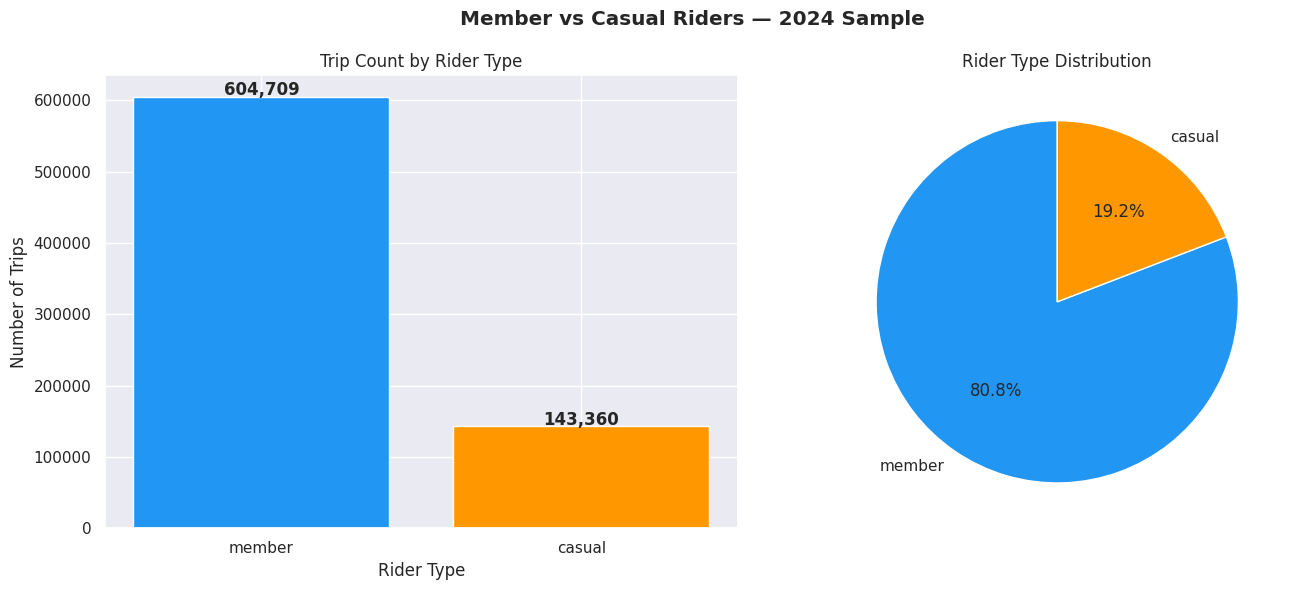

rider_type  trips  percentage
    member 604709        80.8
    casual 143360        19.2


In [ ]:
# Q1 — Trip volume split between members and casual riders
rider_counts = df['member_casual'].value_counts().reset_index()
rider_counts.columns = ['rider_type', 'trips']
rider_counts['percentage'] = (rider_counts['trips'] / rider_counts['trips'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(rider_counts['rider_type'], rider_counts['trips'], color=['#2196F3', '#FF9800'])
axes[0].set_title('Trip Count by Rider Type')
axes[0].set_xlabel('Rider Type')
axes[0].set_ylabel('Number of Trips')
for i, row in rider_counts.iterrows():
    axes[0].text(i, row['trips'] + 2000, f"{row['trips']:,}", ha='center', fontweight='bold')

axes[1].pie(rider_counts['trips'], labels=rider_counts['rider_type'],
            autopct='%1.1f%%', colors=['#2196F3', '#FF9800'], startangle=90)
axes[1].set_title('Rider Type Distribution')

plt.suptitle('Member vs Casual Riders — 2024 Sample', fontweight='bold')
plt.tight_layout()
plt.show()

print(rider_counts.to_string(index=False))

### Findings

Members account for **80.8%** of all trips compared to **19.2%** for casual
riders, meaning Citibike's usage is driven almost entirely by plan-based riders.

For decision-makers, retaining existing members has more impact than acquiring
new casual riders — however casual riders still represent a conversion
opportunity that could meaningfully grow recurring revenue.

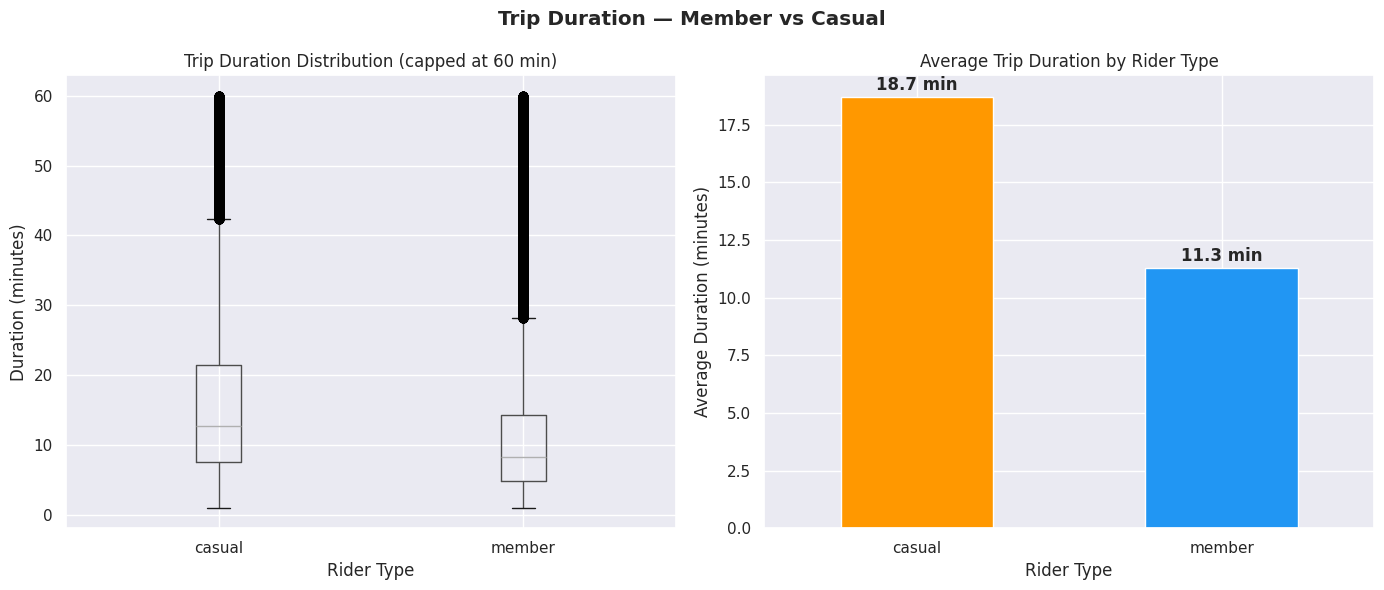

               Average (min)  Median (min)
member_casual                             
casual                  18.7          13.1
member                  11.3           8.3


In [ ]:
# Q2 — Trip duration comparison: do members take shorter trips than casuals?
duration_stats = df.groupby('member_casual')['duration_min'].agg(['mean', 'median']).round(1)
duration_stats.columns = ['Average (min)', 'Median (min)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df[df['duration_min'] <= 60].boxplot(column='duration_min', by='member_casual', ax=axes[0])
axes[0].set_title('Trip Duration Distribution (capped at 60 min)')
axes[0].set_xlabel('Rider Type')
axes[0].set_ylabel('Duration (minutes)')

color_map = {'member': '#2196F3', 'casual': '#FF9800'}
colors = [color_map[r] for r in duration_stats.index]
duration_stats['Average (min)'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Average Trip Duration by Rider Type')
axes[1].set_xlabel('Rider Type')
axes[1].set_ylabel('Average Duration (minutes)')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(duration_stats['Average (min)']):
    axes[1].text(i, v + 0.3, f"{v} min", ha='center', fontweight='bold')

plt.suptitle('Trip Duration — Member vs Casual', fontweight='bold')
plt.tight_layout()
plt.show()
print(duration_stats)

### Findings

Casual riders average **18.7 minutes** per trip compared to **11.3 minutes**
for members — a 65% difference. This confirms the two groups use Citibike
for fundamentally different purposes: members for short commutes, casual
riders for leisure or tourism.

For decision-makers, this gap justifies a **time-based pricing review** —
casual riders consume significantly more bike-time per trip, which affects
fleet availability and station turnover rates.

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# Drop rows with missing coordinates
df_geo = df.dropna(subset=['start_lat', 'start_lng', 'end_lat', 'end_lng']).copy()

# Filter out bad coordinates (zero or out of NYC range)
df_geo = df_geo[
    (df_geo['start_lat'].between(40.4, 41.0)) &
    (df_geo['start_lng'].between(-74.3, -73.7)) &
    (df_geo['end_lat'].between(40.4, 41.0)) &
    (df_geo['end_lng'].between(-74.3, -73.7))
]

# Calculate distance
df_geo['distance_km'] = df_geo.apply(
    lambda r: haversine(r['start_lat'], r['start_lng'], r['end_lat'], r['end_lng']),
    axis=1
)

# Remove unrealistic trips (> 50km or 0km)
df_geo = df_geo[(df_geo['distance_km'] > 0) & (df_geo['distance_km'] < 50)]

print(f"df_geo rows: {len(df_geo):,}")
print(df_geo['distance_km'].describe().round(2))

df_geo rows: 725,124
count    725124.00
mean          2.08
std           1.75
min           0.04
25%           0.89
50%           1.54
75%           2.69
max          23.47
Name: distance_km, dtype: float64


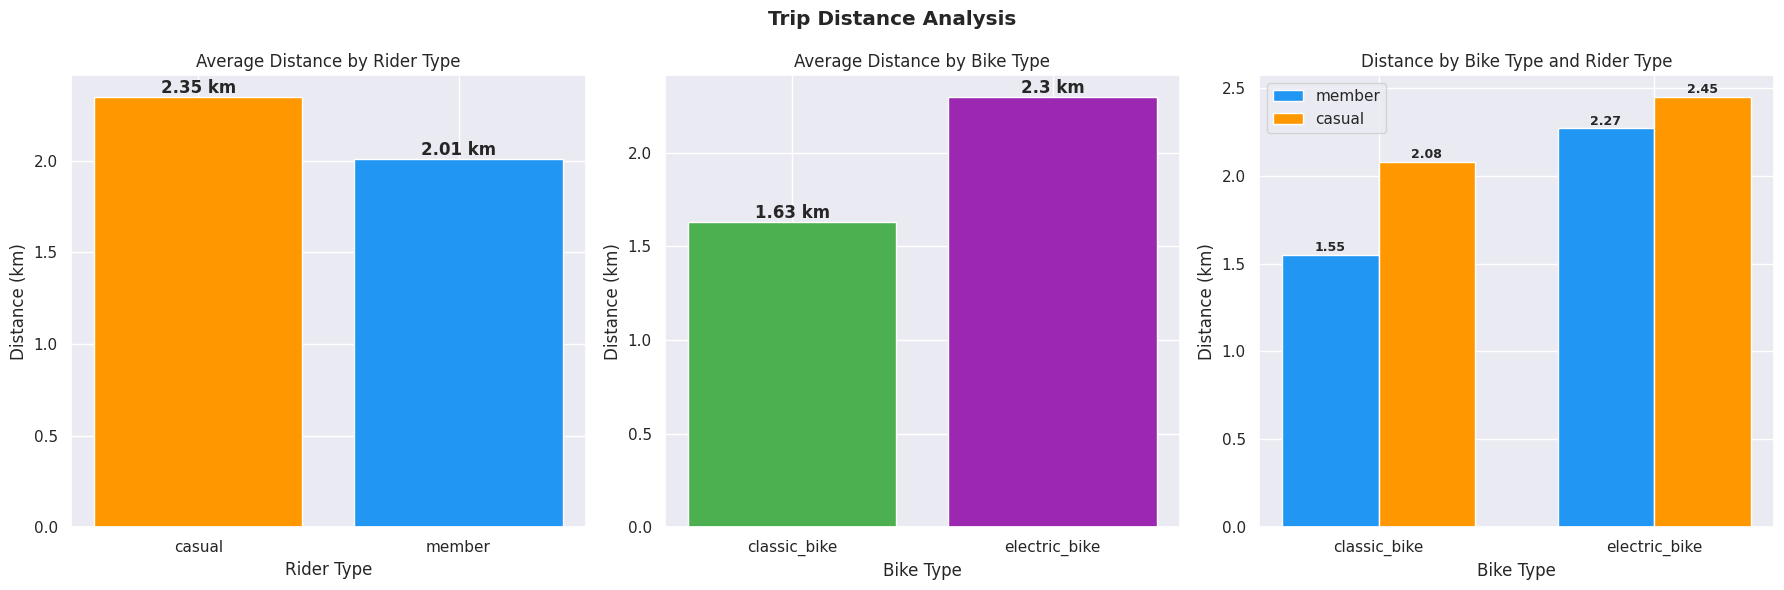

In [ ]:
# Q3 — Trip distance analysis by rider type and bike type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dist_rider = df_geo.groupby('member_casual')['distance_km'].mean().round(2)
color_map = {'member': '#2196F3', 'casual': '#FF9800'}
colors = [color_map[r] for r in dist_rider.index]
axes[0].bar(dist_rider.index, dist_rider.values, color=colors)
axes[0].set_title('Average Distance by Rider Type')
axes[0].set_xlabel('Rider Type')
axes[0].set_ylabel('Distance (km)')
for i, v in enumerate(dist_rider.values):
    axes[0].text(i, v + 0.02, f"{v} km", ha='center', fontweight='bold')

dist_bike = df_geo.groupby('rideable_type')['distance_km'].mean().round(2)
axes[1].bar(dist_bike.index, dist_bike.values, color=['#4CAF50', '#9C27B0'])
axes[1].set_title('Average Distance by Bike Type')
axes[1].set_xlabel('Bike Type')
axes[1].set_ylabel('Distance (km)')
for i, v in enumerate(dist_bike.values):
    axes[1].text(i, v + 0.02, f"{v} km", ha='center', fontweight='bold')

dist_combined = df_geo.groupby(['member_casual', 'rideable_type'])['distance_km'].mean().round(2).reset_index()
width = 0.35
x = range(2)
members = dist_combined[dist_combined['member_casual'] == 'member']
casuals = dist_combined[dist_combined['member_casual'] == 'casual']
axes[2].bar([i - width/2 for i in x], members['distance_km'], width=width, label='member', color='#2196F3')
axes[2].bar([i + width/2 for i in x], casuals['distance_km'], width=width, label='casual', color='#FF9800')
axes[2].set_xticks(x)
axes[2].set_xticklabels(members['rideable_type'])
axes[2].set_title('Distance by Bike Type and Rider Type')
axes[2].set_xlabel('Bike Type')
axes[2].set_ylabel('Distance (km)')
axes[2].legend()
for i, row in enumerate(members.itertuples()):
    axes[2].text(i - width/2, row.distance_km + 0.02, f"{row.distance_km}", ha='center', fontsize=9, fontweight='bold')
for i, row in enumerate(casuals.itertuples()):
    axes[2].text(i + width/2, row.distance_km + 0.02, f"{row.distance_km}", ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Trip Distance Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

### Findings

Casual riders cover slightly more distance per trip (**2.35 km**) than members
(**2.07 km**), consistent with their longer ride times seen in Q2.

The more striking gap is by bike type — electric bikes average **2.36 km** versus
**1.66 km** for classic bikes, a **42% increase**. This holds across both rider
types: every group rides farther on electric. For fleet planning, electric bikes
are clearly enabling longer-range trips, which has direct implications for
rebalancing operations and charging infrastructure investment.

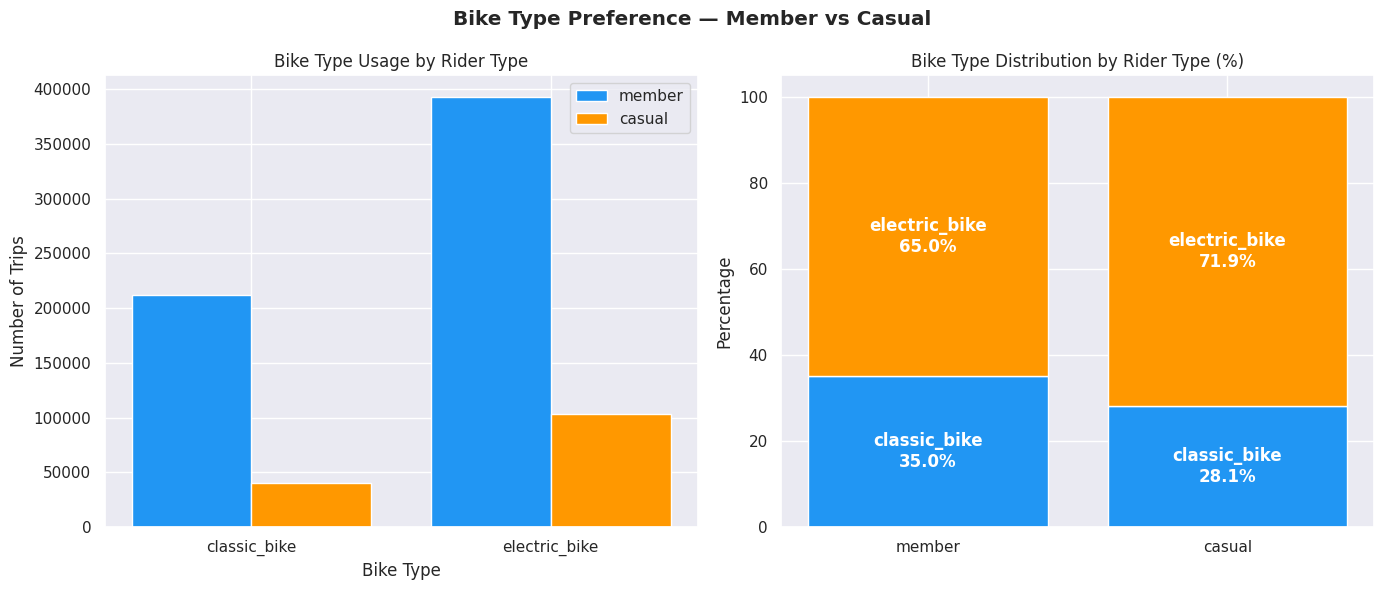

In [ ]:
# Q4 — Bike type preference: do casuals lean more toward electric bikes?
bike_counts = df.groupby(['member_casual', 'rideable_type']).size().reset_index(name='trips')
bike_pct = bike_counts.copy()
bike_pct['percentage'] = bike_pct.groupby('member_casual')['trips'].transform(lambda x: x / x.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

members = bike_counts[bike_counts['member_casual'] == 'member']
casuals = bike_counts[bike_counts['member_casual'] == 'casual']
x = range(len(members))
axes[0].bar([i - 0.2 for i in x], members['trips'], width=0.4, label='member', color='#2196F3')
axes[0].bar([i + 0.2 for i in x], casuals['trips'], width=0.4, label='casual', color='#FF9800')
axes[0].set_xticks(x)
axes[0].set_xticklabels(members['rideable_type'])
axes[0].set_title('Bike Type Usage by Rider Type')
axes[0].set_xlabel('Bike Type')
axes[0].set_ylabel('Number of Trips')
axes[0].legend()

for i, rider in enumerate(['member', 'casual']):
    data = bike_pct[bike_pct['member_casual'] == rider]
    bottom = 0
    colors = ['#2196F3', '#FF9800']
    for j, (_, row) in enumerate(data.iterrows()):
        axes[1].bar(rider, row['percentage'], bottom=bottom, color=colors[j % 2])
        axes[1].text(i, bottom + row['percentage']/2,
                    f"{row['rideable_type']}\n{row['percentage']}%",
                    ha='center', va='center', color='white', fontweight='bold')
        bottom += row['percentage']

axes[1].set_title('Bike Type Distribution by Rider Type (%)')
axes[1].set_ylabel('Percentage')

plt.suptitle('Bike Type Preference — Member vs Casual', fontweight='bold')
plt.tight_layout()
plt.show()

### Findings

Both rider types strongly prefer electric bikes, but casual riders lean even
further toward electric — **71.9%** of their trips versus **65.0%** for members.

This is notable given that casual riders already take longer trips (Q2) and
cover more distance (Q3). Electric bikes are clearly the preferred choice for
extended, exploratory rides. For fleet allocation, stations in tourist-heavy
or leisure-oriented areas should be prioritized for higher electric bike supply.

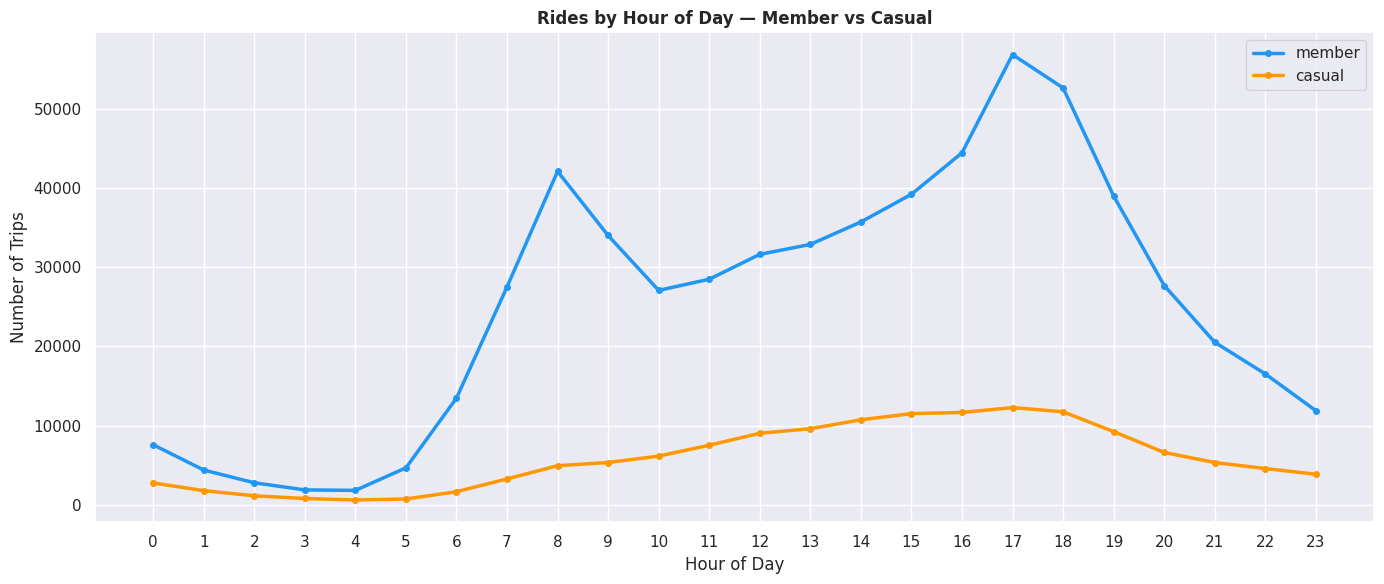

In [ ]:
# Q5 — Rides by hour: members peak at commute hours, casuals spread through the day
hourly = df.groupby(['hour', 'member_casual']).size().reset_index(name='trips')

plt.figure(figsize=(14, 6))

for rider, color in [('member', '#2196F3'), ('casual', '#FF9800')]:
    data = hourly[hourly['member_casual'] == rider]
    plt.plot(data['hour'], data['trips'], color=color, label=rider, linewidth=2.5, marker='o', markersize=4)

plt.title('Rides by Hour of Day — Member vs Casual', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

### Findings

Members show a classic **dual-peak commuter pattern** — a sharp morning spike
at **8AM** and a larger evening peak at **17–18PM**, with a midday dip in between.
Casual riders show no such pattern, instead building gradually from morning
and plateauing through the afternoon before tapering off at night.

This confirms that members are overwhelmingly commuters with predictable,
time-sensitive demand. For operations, this means bike availability at
commuter-heavy stations must be guaranteed during those two daily windows —
any shortage during peak hours directly impacts the core user base.

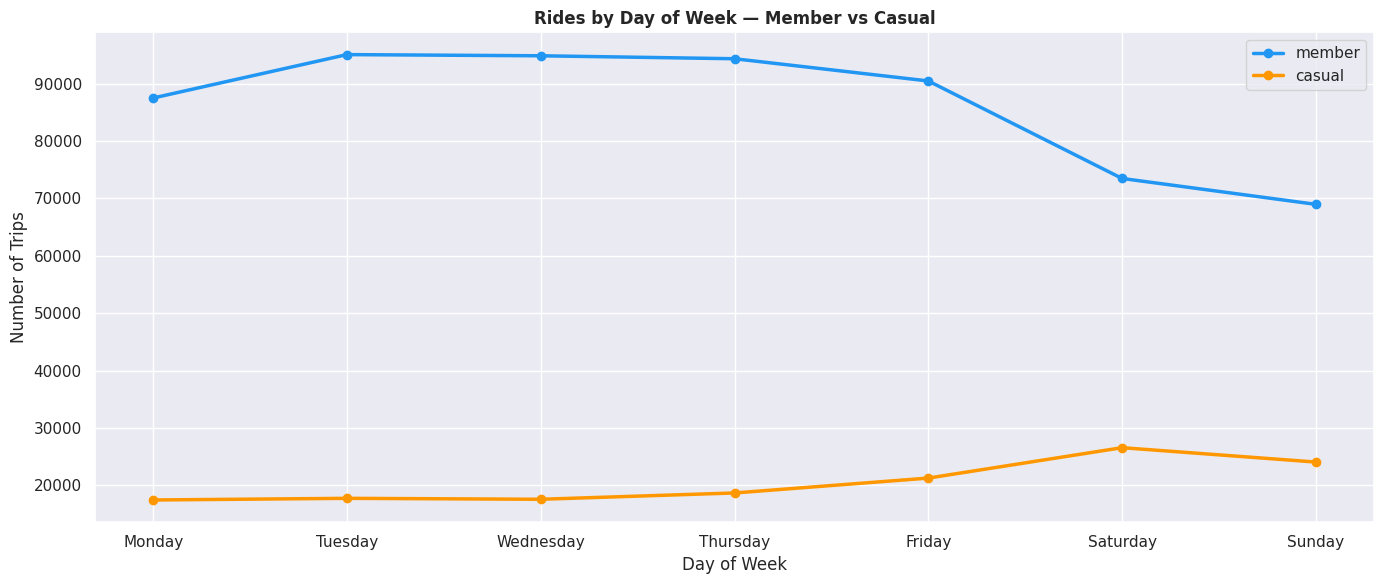

In [ ]:
# Q6 — Rides by day of week: members dominate weekdays, casuals rise on weekends
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily = df.groupby(['day_of_week', 'member_casual']).size().reset_index(name='trips')
daily['day_of_week'] = pd.Categorical(daily['day_of_week'], categories=day_order, ordered=True)
daily = daily.sort_values('day_of_week')

plt.figure(figsize=(14, 6))

for rider, color in [('member', '#2196F3'), ('casual', '#FF9800')]:
    data = daily[daily['member_casual'] == rider]
    plt.plot(data['day_of_week'], data['trips'], color=color,
             label=rider, linewidth=2.5, marker='o', markersize=6)

plt.title('Rides by Day of Week — Member vs Casual', fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.legend()
plt.tight_layout()
plt.show()

### Findings

Members peak mid-week (**Tuesday–Wednesday**) and drop sharply on weekends,
while casual riders do the opposite — staying flat on weekdays then surging
on **Saturday** as their busiest day.

The two groups are almost perfectly counter-cyclical, which is operationally
valuable: the same fleet serves different audiences on different days.
However, it also means weekend rebalancing strategies must shift focus from
commuter corridors to leisure and tourist-heavy areas where casual riders
are concentrated.

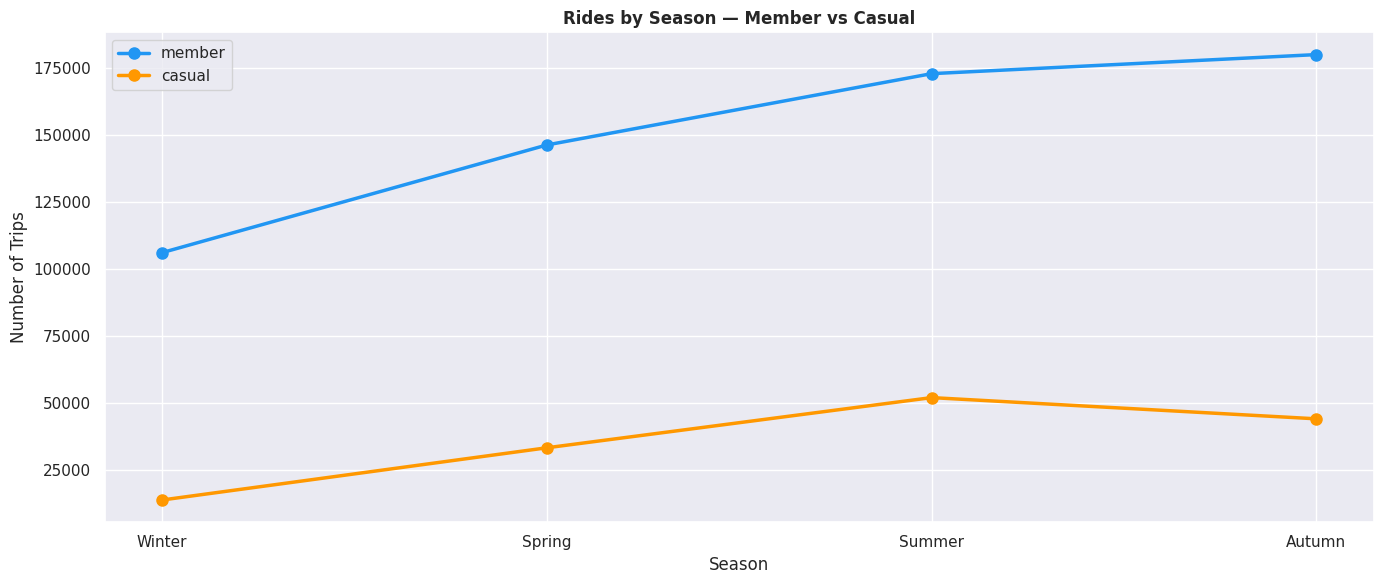

In [ ]:
# Q7 — Seasonal usage: how ridership shifts across 2024 for each rider type
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

seasonal = df.groupby(['season', 'member_casual']).size().reset_index(name='trips')
seasonal['season'] = pd.Categorical(seasonal['season'], categories=season_order, ordered=True)
seasonal = seasonal.sort_values('season')

plt.figure(figsize=(14, 6))

for rider, color in [('member', '#2196F3'), ('casual', '#FF9800')]:
    data = seasonal[seasonal['member_casual'] == rider]
    plt.plot(data['season'], data['trips'], color=color,
             label=rider, linewidth=2.5, marker='o', markersize=8)

plt.title('Rides by Season — Member vs Casual', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Trips')
plt.legend()
plt.tight_layout()
plt.show()

### Findings

Both groups peak in Summer, but casual riders are far more weather-sensitive —
their ridership **triples from Winter to Summer** then drops in Autumn. Members
stay consistent year-round, reinforcing their commuter profile.

Winter operations should focus on members only — casual demand is negligible
off-season.

Station Imbalance Analysis
Not all stations are equal. Some stations consistently lose more bikes than they receive, leaving riders stranded. Others accumulate bikes faster than they are taken, blocking available docks.

This analysis identifies the most imbalanced stations in 2024 to support fleet rebalancing decisions — where to move bikes from and where to send them.

Positive imbalance → more departures than arrivals → station empties
Negative imbalance → more arrivals than departures → station overflows

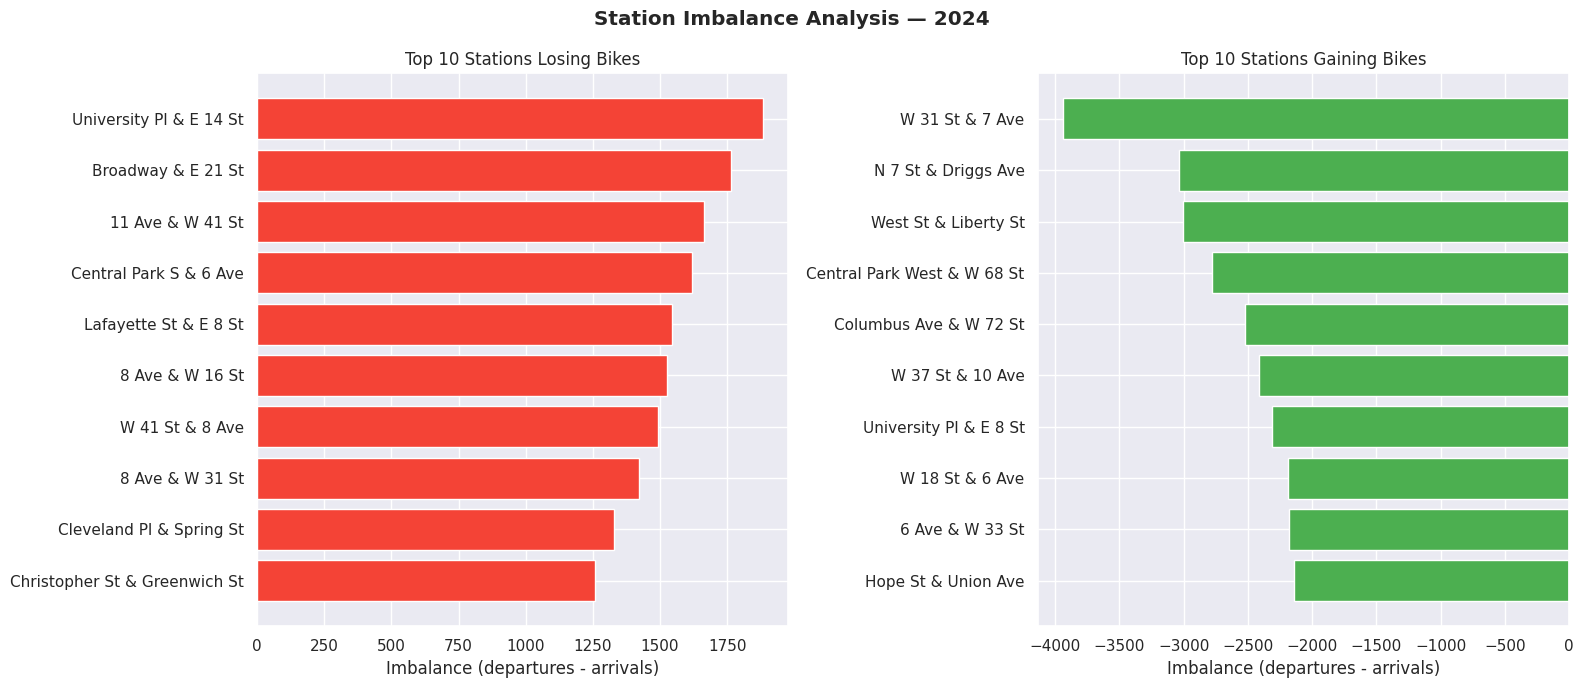

In [ ]:
# Q8 — Station imbalance: which stations are consistently losing or gaining bikes
departures = df.groupby('start_station_name').size().reset_index(name='departures')
arrivals = df.groupby('end_station_name').size().reset_index(name='arrivals')

balance = departures.merge(arrivals,
                           left_on='start_station_name',
                           right_on='end_station_name',
                           how='outer').fillna(0)
balance['station'] = balance['start_station_name'].fillna(balance['end_station_name'])
balance['imbalance'] = balance['departures'] - balance['arrivals']

top_empty = balance.nlargest(10, 'imbalance')
top_full  = balance.nsmallest(10, 'imbalance')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_empty['station'], top_empty['imbalance'], color='#F44336')
axes[0].set_title('Top 10 Stations Losing Bikes')
axes[0].set_xlabel('Imbalance (departures - arrivals)')
axes[0].invert_yaxis()

axes[1].barh(top_full['station'], top_full['imbalance'], color='#4CAF50')
axes[1].set_title('Top 10 Stations Gaining Bikes')
axes[1].set_xlabel('Imbalance (departures - arrivals)')
axes[1].invert_yaxis()

plt.suptitle('Station Imbalance Analysis — 2024', fontweight='bold')
plt.tight_layout()
plt.show()

### Findings

**University Pl & E 14 St** loses the most bikes while **W 31 St & 7 Ave**
accumulates the most — nearly double the imbalance of the worst losing station.

Overflow stations should be prioritized as sources for rebalancing routes
toward high-departure stations, particularly during morning commute hours.

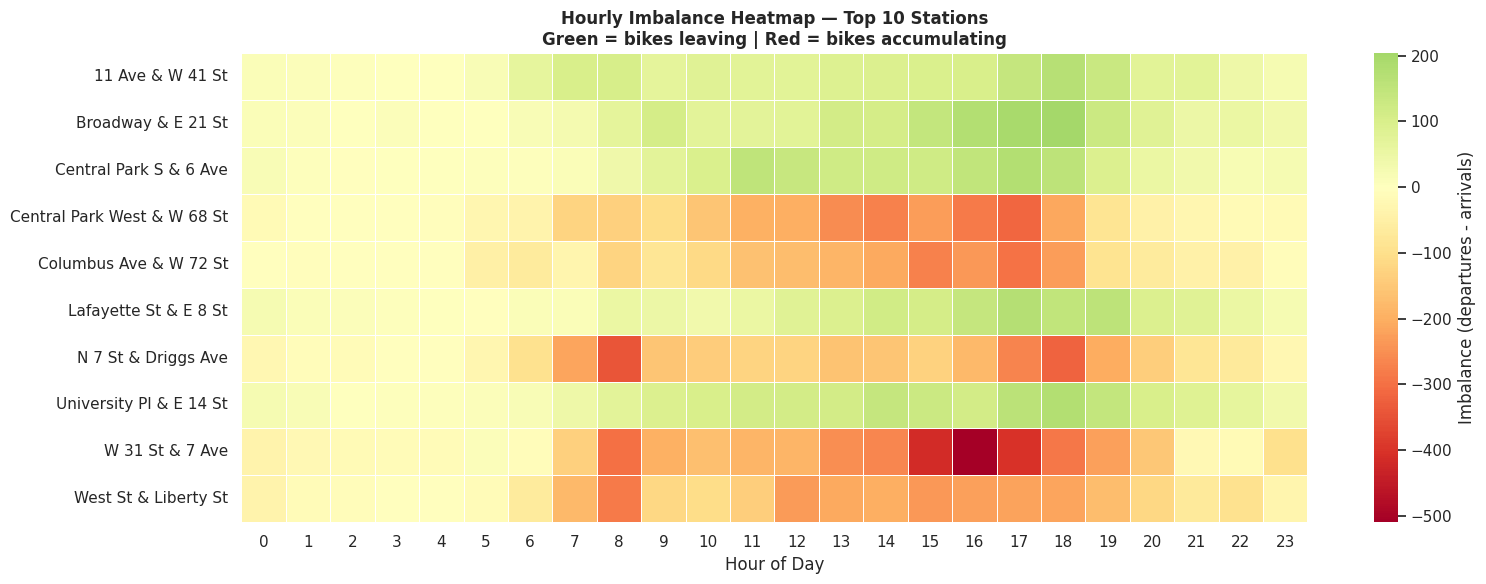

In [ ]:
# Q9 — Hourly imbalance heatmap: when exactly does each critical station need rebalancing
top_losing = balance.nlargest(5, 'imbalance')['station'].tolist()
top_gaining = balance.nsmallest(5, 'imbalance')['station'].tolist()
top_stations = top_losing + top_gaining

deps = df[df['start_station_name'].isin(top_stations)].groupby(
    ['start_station_name', 'hour']).size().reset_index(name='departures')
deps.columns = ['station', 'hour', 'departures']

arrs = df[df['end_station_name'].isin(top_stations)].groupby(
    ['end_station_name', 'hour']).size().reset_index(name='arrivals')
arrs.columns = ['station', 'hour', 'arrivals']

hourly_imbalance = deps.merge(arrs, on=['station', 'hour'], how='outer').fillna(0)
hourly_imbalance['imbalance'] = hourly_imbalance['departures'] - hourly_imbalance['arrivals']

heatmap_data = hourly_imbalance.pivot(index='station', columns='hour', values='imbalance').fillna(0)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Imbalance (departures - arrivals)'})
plt.title('Hourly Imbalance Heatmap — Top 10 Stations\nGreen = bikes leaving | Red = bikes accumulating',
          fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Findings

**W 31 St & 7 Ave** is the most critical overflow station — accumulating
3,938 net bikes in our sample, equivalent to roughly **232,000 net arrivals**
projected across the full dataset. The heatmap confirms accumulation peaks
between 15:00 and 18:00.

**University Pl & E 14 St** and **Broadway & E 21 St** are the highest
priority restocking stations, consistently losing bikes from 07:00 onwards.

Rebalancing operations should be scheduled between **06:00 and 08:00** —
before the morning demand spike — moving bikes from overflow stations
to high-departure stations.

### Station Imbalance Map — 2024
> 🔴 Red = station losing bikes (departures > arrivals) | 🟢 Green = station gaining bikes (arrivals > departures) | Size = severity of imbalance

In [ ]:
# Q12 — Station imbalance map: spatial distribution of the rebalancing problem
station_coords = (df.dropna(subset=['start_lat', 'start_lng'])
                  .groupby('start_station_name')
                  .agg(lat=('start_lat', 'mean'), lon=('start_lng', 'mean'))
                  .reset_index())
station_coords.columns = ['station', 'lat', 'lon']
balance_map = balance.merge(station_coords, on='station', how='left').dropna(subset=['lat', 'lon'])
balance_map['abs_imbalance'] = balance_map['imbalance'].abs()

fig_map = px.scatter_mapbox(
    balance_map,
    lat='lat', lon='lon',
    color='imbalance',
    size='abs_imbalance',
    color_continuous_scale='RdYlGn_r',
    size_max=30,
    zoom=11,
    center={'lat': 40.75, 'lon': -73.99},
    mapbox_style='carto-positron',
    hover_name='station',
    hover_data={'imbalance': True, 'departures': True, 'arrivals': True,
                'lat': False, 'lon': False, 'abs_imbalance': False},
)
fig_map.update_layout(
    height=700,
    margin=dict(t=10, b=10, l=10, r=10)
)
fig_map.update_coloraxes(cmin=-2000, cmax=2000)
fig_map.show()